In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import gsw
import numpy as np
from mpl_toolkits.basemap import Basemap

In [2]:
# Get data into dataframe
df = pd.read_csv('../../../WMA_fractions_v2.csv', skiprows=1)

# Preprocess data to only have temperature, salinity and dissolved oxygen
df_ST = df.copy()
df_ST = df_ST[['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]', 'Dissolved_Oxygen_[micro_mol_per_kg]', 'Depth_[m]', 'Latitude_[deg_N]', 'Longitude_[deg_E]','Datetime_[UTC]']]
df_ST['year'] = pd.to_datetime(df_ST['Datetime_[UTC]']).dt.year
df_ST['month'] = pd.to_datetime(df_ST['Datetime_[UTC]']).dt.month
df_ST = df_ST[['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]', 'Dissolved_Oxygen_[micro_mol_per_kg]', 'Depth_[m]', 'Latitude_[deg_N]', 'Longitude_[deg_E]','year', 'month']]

# Sample randomly by temporal bins (1 year bins)

In [3]:
# Make df for each year and sample spatially for that year 
unique_years = df_ST['year'].unique()
for i in range(len(unique_years)):
    df_sampled_i = df_ST[df_ST['year'] == unique_years[i]]
    df_sampled_i = df_sampled_i.sample(n=1000, random_state=22, replace=True)

    # concatenate the sampled dataframes for each year
    if i == 0:
        df_sampled = df_sampled_i
    else:
        df_sampled = pd.concat([df_sampled, df_sampled_i], ignore_index=True)

In [4]:
def plot_heatmap(ds_cleaned, n_lon_bins=72, n_lat_bins=9, bin_max=None):
    lon_min, lon_max = -180, 180
    lat_min, lat_max = 45, 90
    resolution = 'l'

    # Equal-area bins: uniform in longitude, uniform in sin(latitude)
    lon_bins = np.linspace(lon_min, lon_max, n_lon_bins + 1)
    sin_min = np.sin(np.radians(lat_min))
    sin_max = np.sin(np.radians(lat_max))
    sin_bins = np.linspace(sin_min, sin_max, n_lat_bins + 1)
    lat_bins = np.degrees(np.arcsin(sin_bins))

    # Compute max depth per bin
    n_lon = len(lon_bins) - 1
    n_lat = len(lat_bins) - 1
    H = np.zeros((n_lon, n_lat))

    lon_vals = ds_cleaned['Longitude_[deg_E]'].values
    lat_vals = ds_cleaned['Latitude_[deg_N]'].values
    depth_vals = ds_cleaned['Depth_[m]'].values

    lon_idx = np.digitize(lon_vals, lon_bins) - 1
    lat_idx = np.digitize(lat_vals, lat_bins) - 1

    for i in range(len(lon_vals)):
        li, lj = lon_idx[i], lat_idx[i]
        if 0 <= li < n_lon and 0 <= lj < n_lat:
            if depth_vals[i] > H[li, lj]:
                H[li, lj] = depth_vals[i]

    fig = plt.figure(figsize=(8,8), dpi=300)
    m = Basemap(projection='npstere', boundinglat=lat_min, lon_0=0, resolution=resolution)

    m.drawcoastlines()
    m.fillcontinents(color='grey', lake_color='lightblue')

    # Draw sine-lat bin edges as lightgrey lines
    # Latitude lines (at each lat_bins edge)
    for lat in lat_bins:
        lons = np.linspace(lon_min, lon_max, 500)
        lats = np.full_like(lons, lat)
        x, y = m(lons, lats)
        m.plot(x, y, color='grey', linewidth=0.05, zorder=3)

    # Longitude lines (at each lon_bins edge)
    for lon in lon_bins:
        lats = np.linspace(lat_min, lat_max, 500)
        lons = np.full_like(lats, lon)
        x, y = m(lons, lats)
        m.plot(x, y, color='grey', linewidth=0.05, zorder=3)

    # Plot data on top
    X, Y = np.meshgrid(lon_bins, lat_bins)
    X_map, Y_map = m(X, Y)

    cmap = plt.get_cmap('Wistia').copy()
    cmap.set_under(color='white', alpha=1.0)
    cmap.set_over(color='white', alpha=1.0)

    if bin_max is None:
        bin_max = H.max()

    m.pcolormesh(X_map, Y_map, H.T, cmap=cmap, vmin=1, vmax=bin_max)

    # Redraw coastlines on top of pcolormesh
    m.drawcoastlines()
    m.fillcontinents(color='lightgrey', lake_color='lightblue')

    cbar = m.colorbar(location='bottom', pad="5%")
    cbar.set_label('Max Depth [m]')

    plt.xticks([])
    plt.yticks([])
    plt.title('Max Depth per Bin')

    plt.show()
    print(f'bin max={bin_max}')

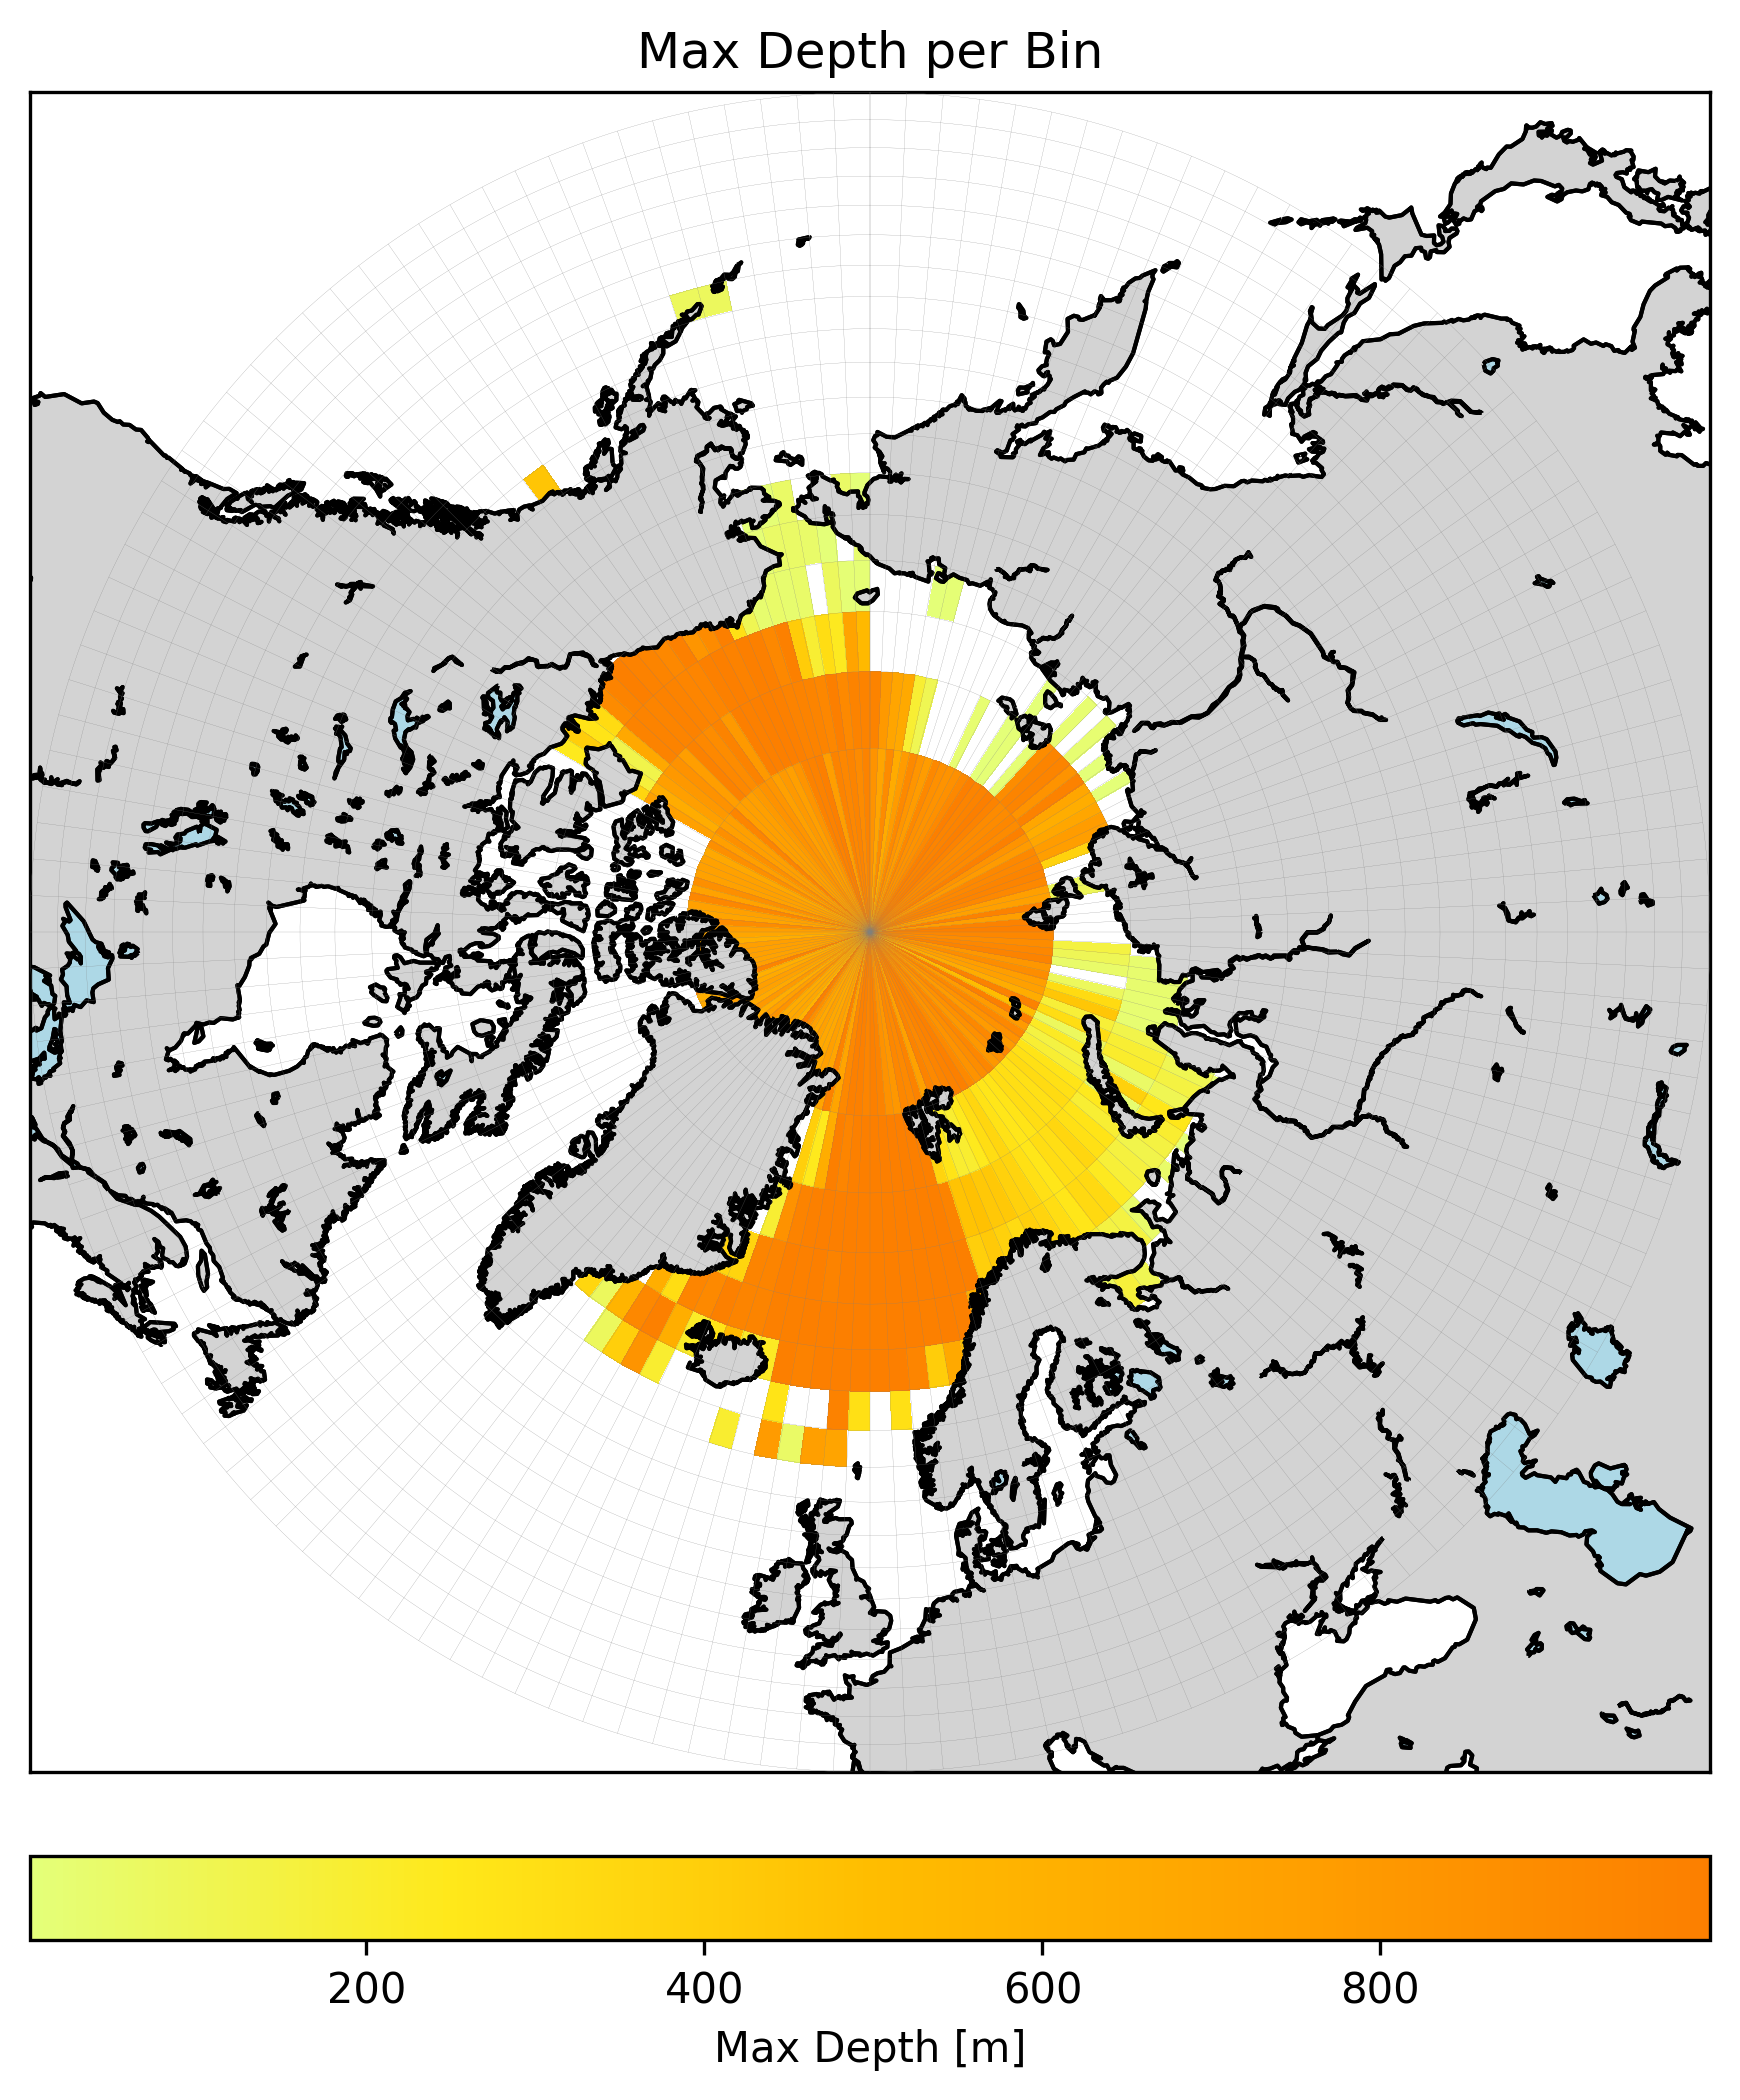

bin max=995.0


In [5]:
plot_heatmap(df_sampled, n_lon_bins=144, n_lat_bins=18)

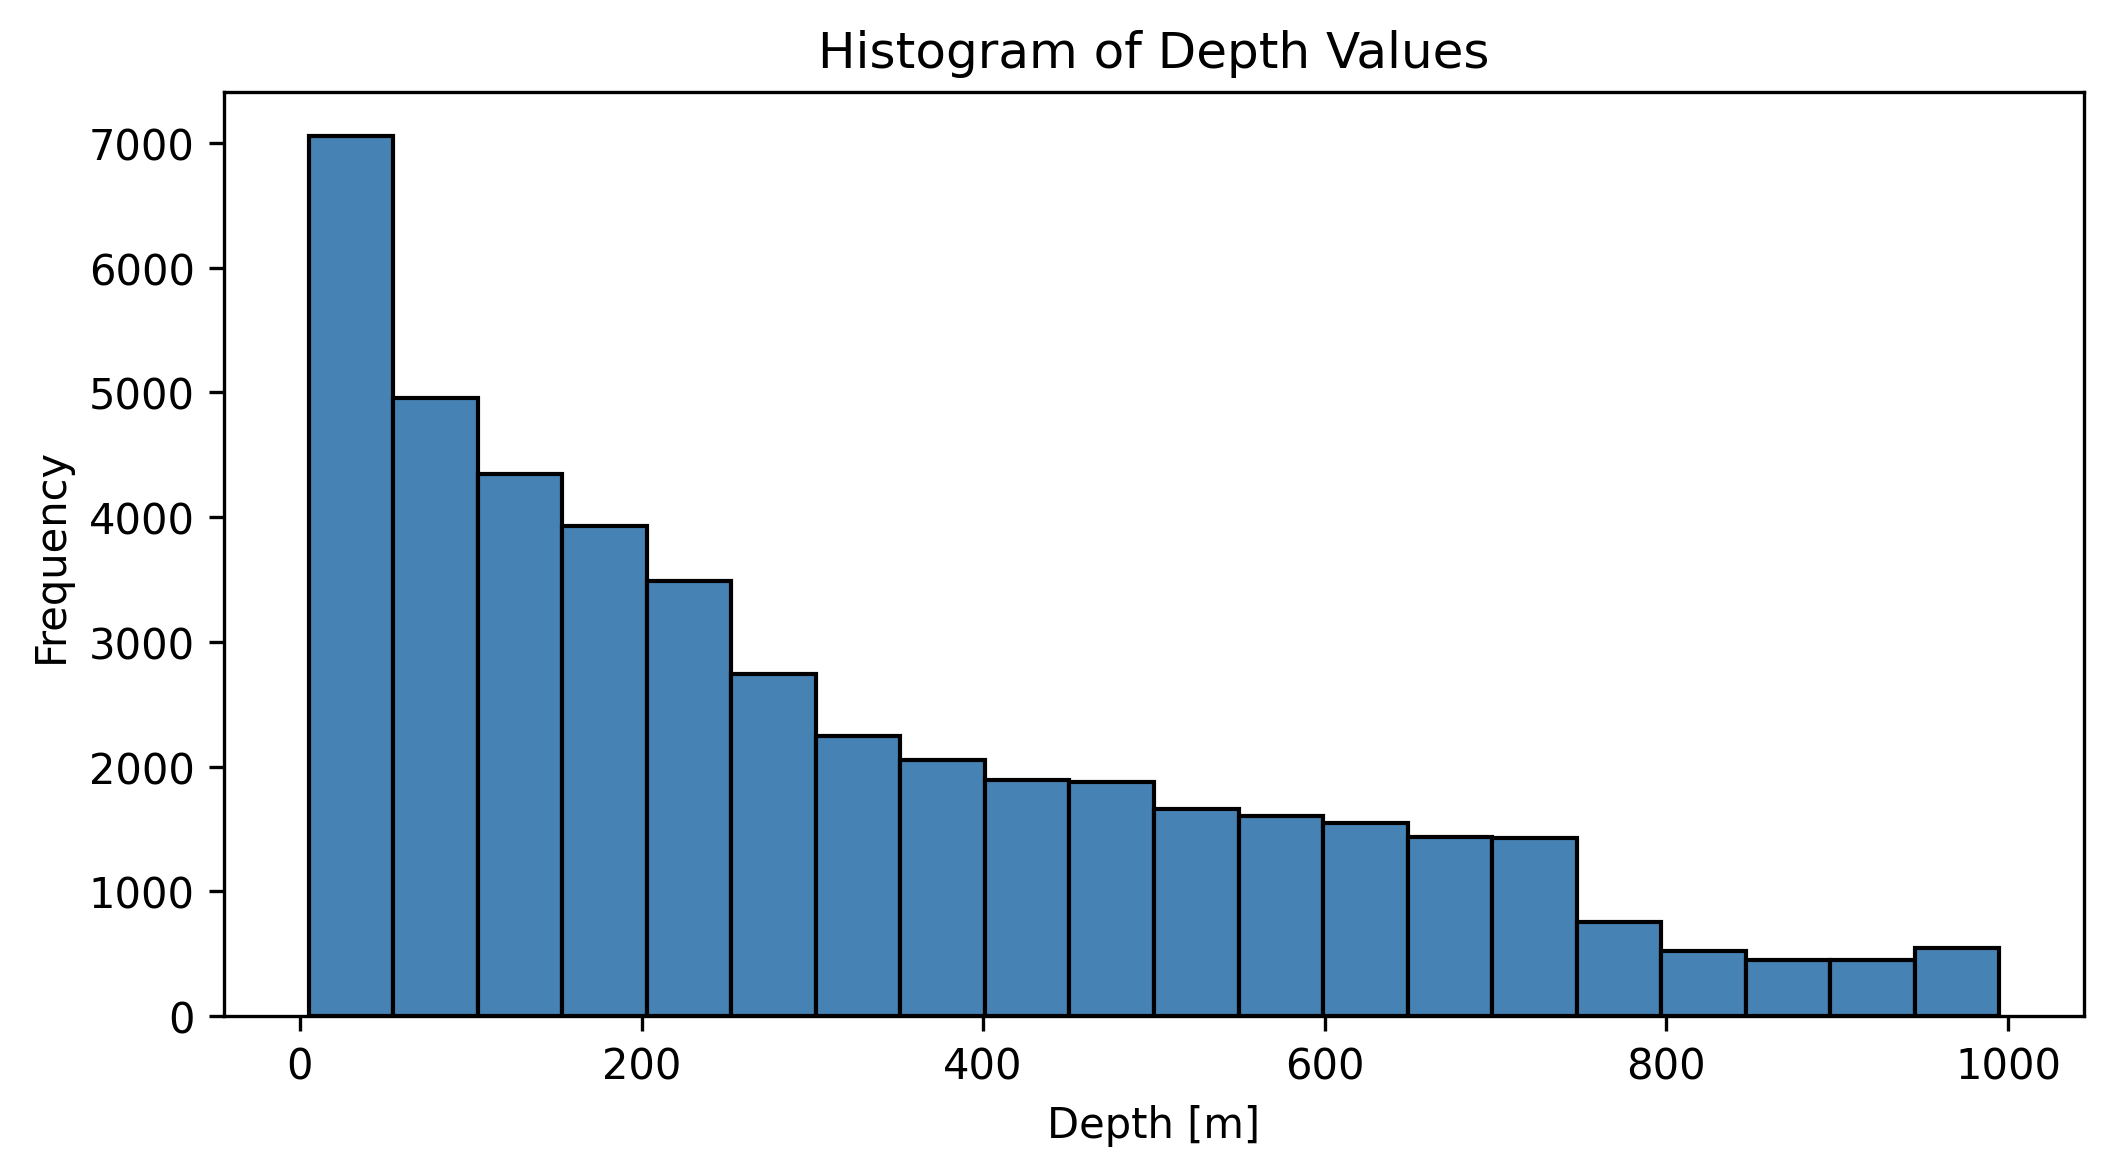

In [6]:
# plot histogram of depth values
plt.figure(figsize=(8,4), dpi=300)
plt.hist(df_sampled['Depth_[m]'], bins=20, color='steelblue', edgecolor='black')
plt.xlabel('Depth [m]')
plt.ylabel('Frequency')
plt.title('Histogram of Depth Values')
plt.show()

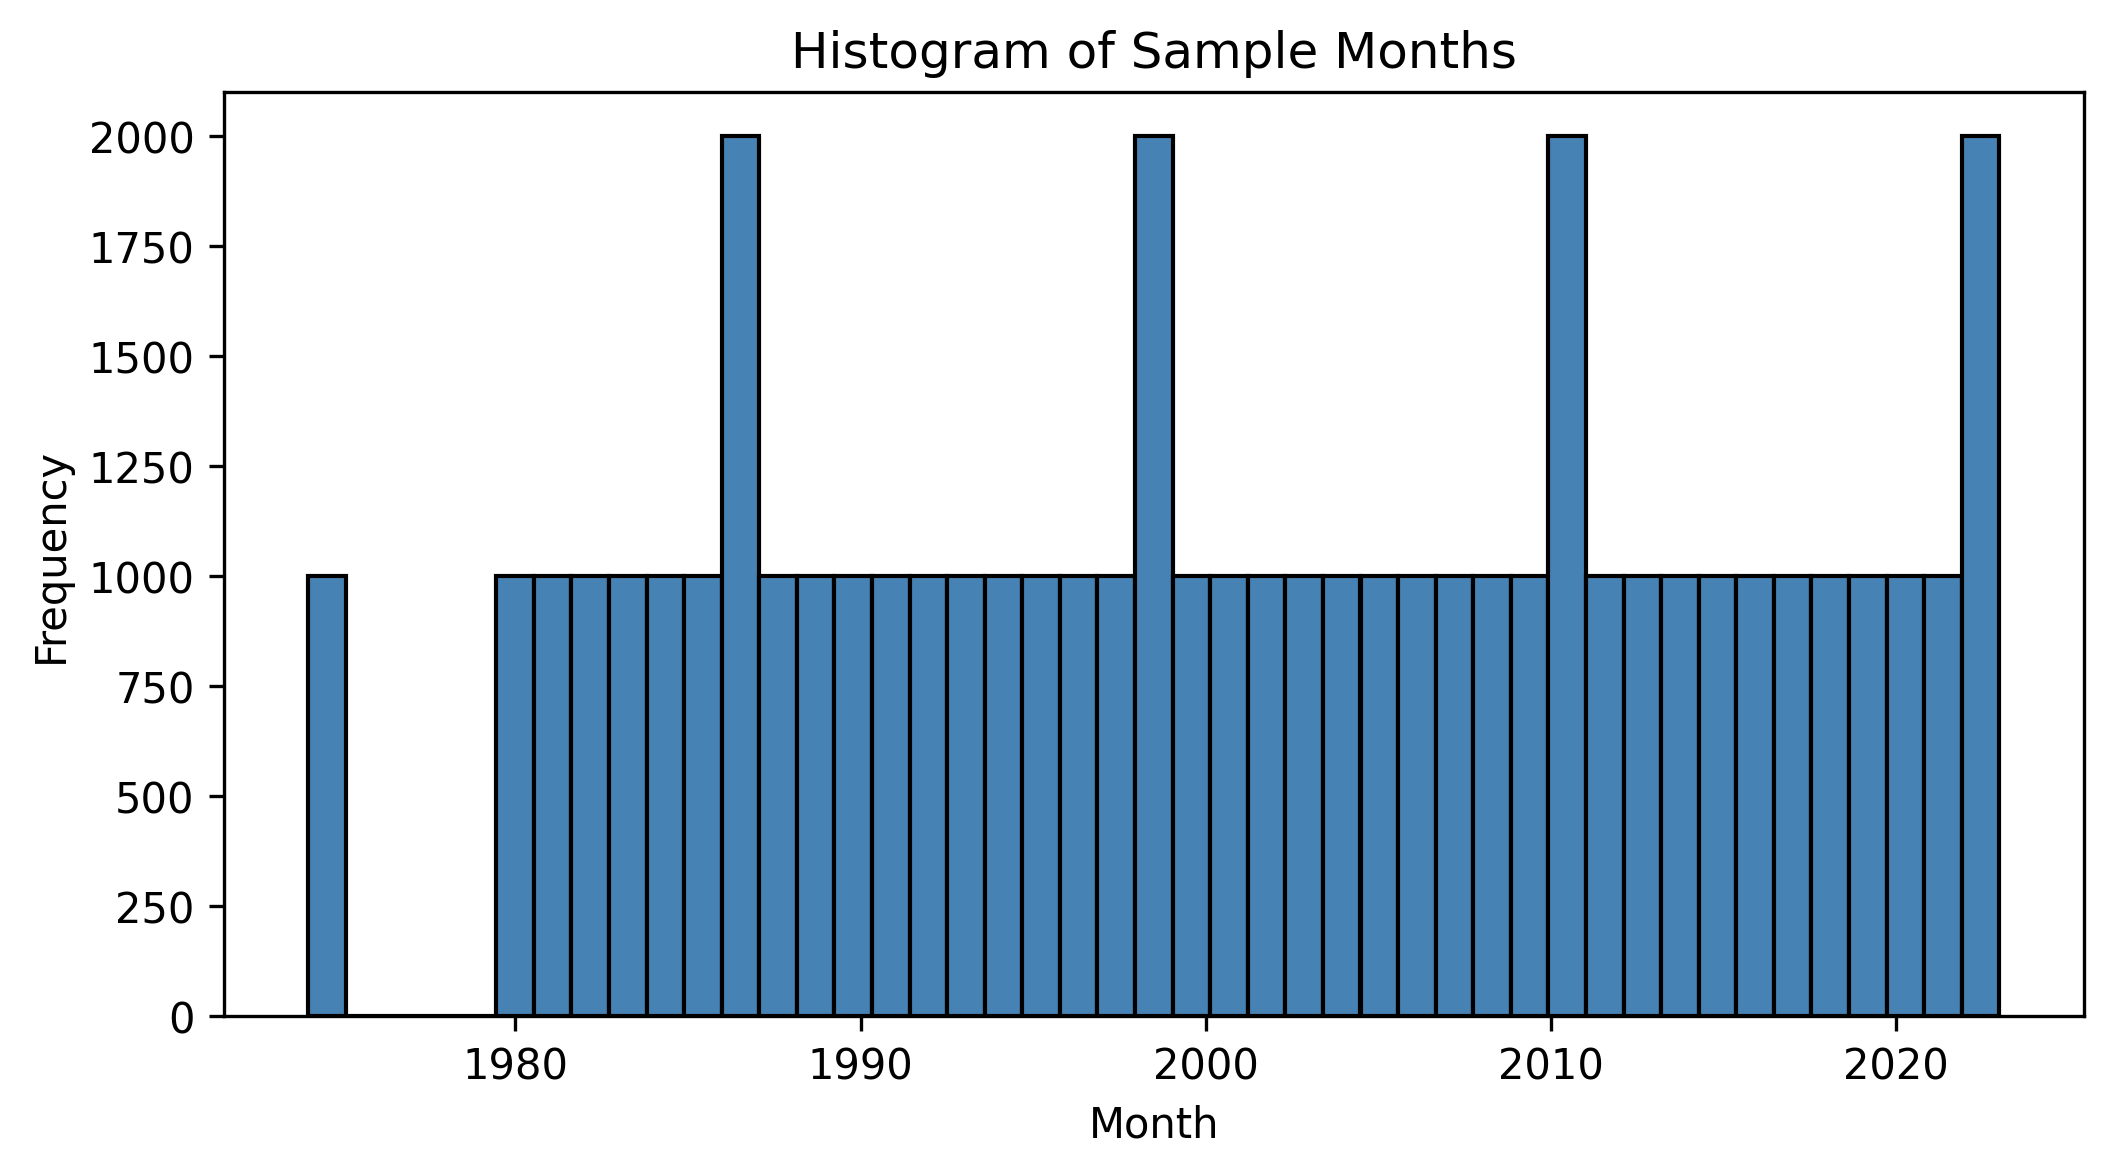

In [7]:
# plot histogram of temporal distribution of samples
plt.figure(figsize=(8,4), dpi=300)
plt.hist(df_sampled['year'], bins=45, color='steelblue', edgecolor='black')
plt.xlabel('Month')
plt.ylabel('Frequency')
plt.title('Histogram of Sample Months')
plt.show()

In [8]:
def plot_heatmap_npts(ds_cleaned, n_lon_bins=72, n_lat_bins=9):
    lon_min, lon_max = -180, 180
    lat_min, lat_max = 45, 90
    resolution = 'l'

    # Equal-area bins: uniform in longitude, uniform in sin(latitude)
    lon_bins = np.linspace(lon_min, lon_max, n_lon_bins + 1)
    sin_min = np.sin(np.radians(lat_min))
    sin_max = np.sin(np.radians(lat_max))
    sin_bins = np.linspace(sin_min, sin_max, n_lat_bins + 1)
    lat_bins = np.degrees(np.arcsin(sin_bins))

    # Find number of points per bin
    count = np.zeros((n_lon_bins, n_lat_bins), dtype=int)
    for i in range(len(lon_bins)-1):
        for j in range(len(lat_bins)-1):
            count[i,j] = ds_cleaned[ds_cleaned['Longitude_[deg_E]'].between(lon_bins[i], lon_bins[i+1]) & ds_cleaned['Latitude_[deg_N]'].between(lat_bins[j], lat_bins[j+1])].shape[0]

    fig = plt.figure(figsize=(8,8), dpi=300)
    m = Basemap(projection='npstere', boundinglat=lat_min, lon_0=0, resolution=resolution)

    m.drawcoastlines()
    m.fillcontinents(color='grey', lake_color='lightblue')

    # Draw sine-lat bin edges as lightgrey lines
    # Latitude lines (at each lat_bins edge)
    for lat in lat_bins:
        lons = np.linspace(lon_min, lon_max, 500)
        lats = np.full_like(lons, lat)
        x, y = m(lons, lats)
        m.plot(x, y, color='grey', linewidth=0.05, zorder=3)

    # Longitude lines (at each lon_bins edge)
    for lon in lon_bins:
        lats = np.linspace(lat_min, lat_max, 500)
        lons = np.full_like(lats, lon)
        x, y = m(lons, lats)
        m.plot(x, y, color='grey', linewidth=0.05, zorder=3)

    # Plot data on top
    X, Y = np.meshgrid(lon_bins, lat_bins)
    X_map, Y_map = m(X, Y)

    cmap = plt.get_cmap('Wistia').copy()
    cmap.set_under(color='white', alpha=1.0)
    cmap.set_over(color='white', alpha=1.0)

    m.pcolormesh(X_map, Y_map, count.T, cmap=cmap, vmin=1, vmax=None)

    # Redraw coastlines on top of pcolormesh
    m.drawcoastlines()
    m.fillcontinents(color='lightgrey', lake_color='lightblue')

    cbar = m.colorbar(location='bottom', pad="5%")
    cbar.set_label('Number of points in bin')

    plt.xticks([])
    plt.yticks([])
    plt.title('Number of Points per Bin')

    plt.show()

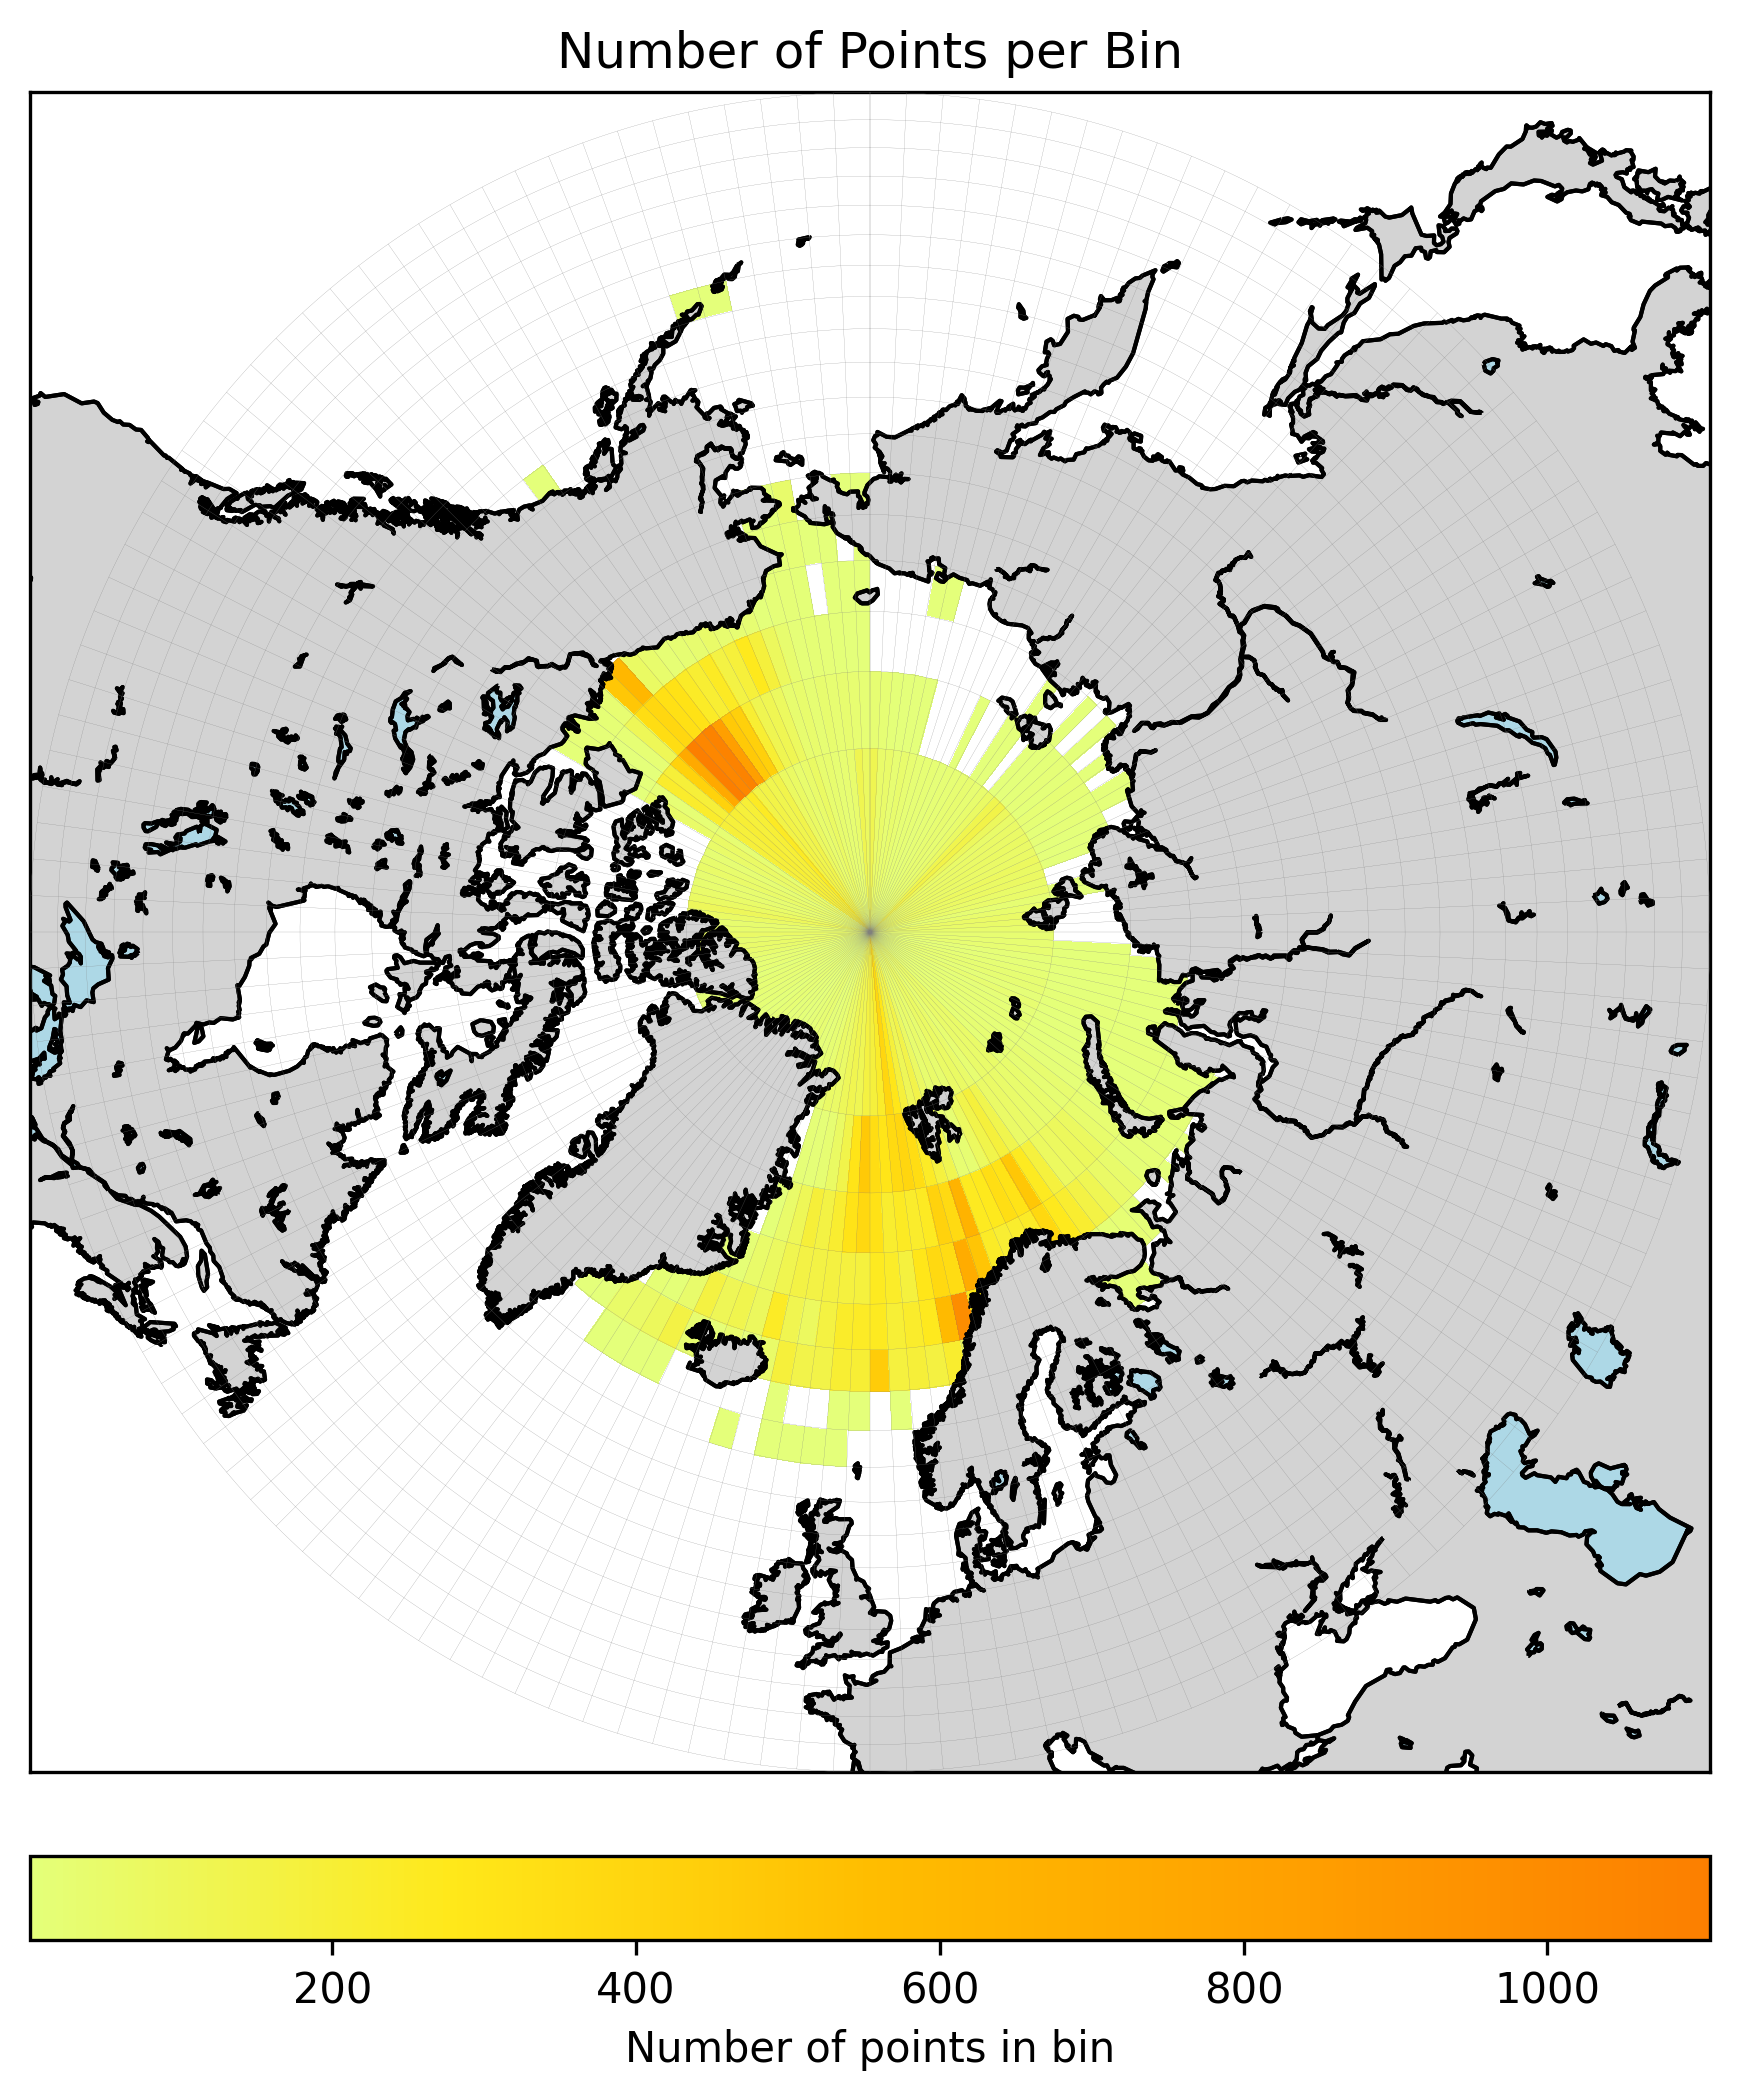

In [9]:
plot_heatmap_npts(df_sampled, n_lon_bins=144, n_lat_bins=18)

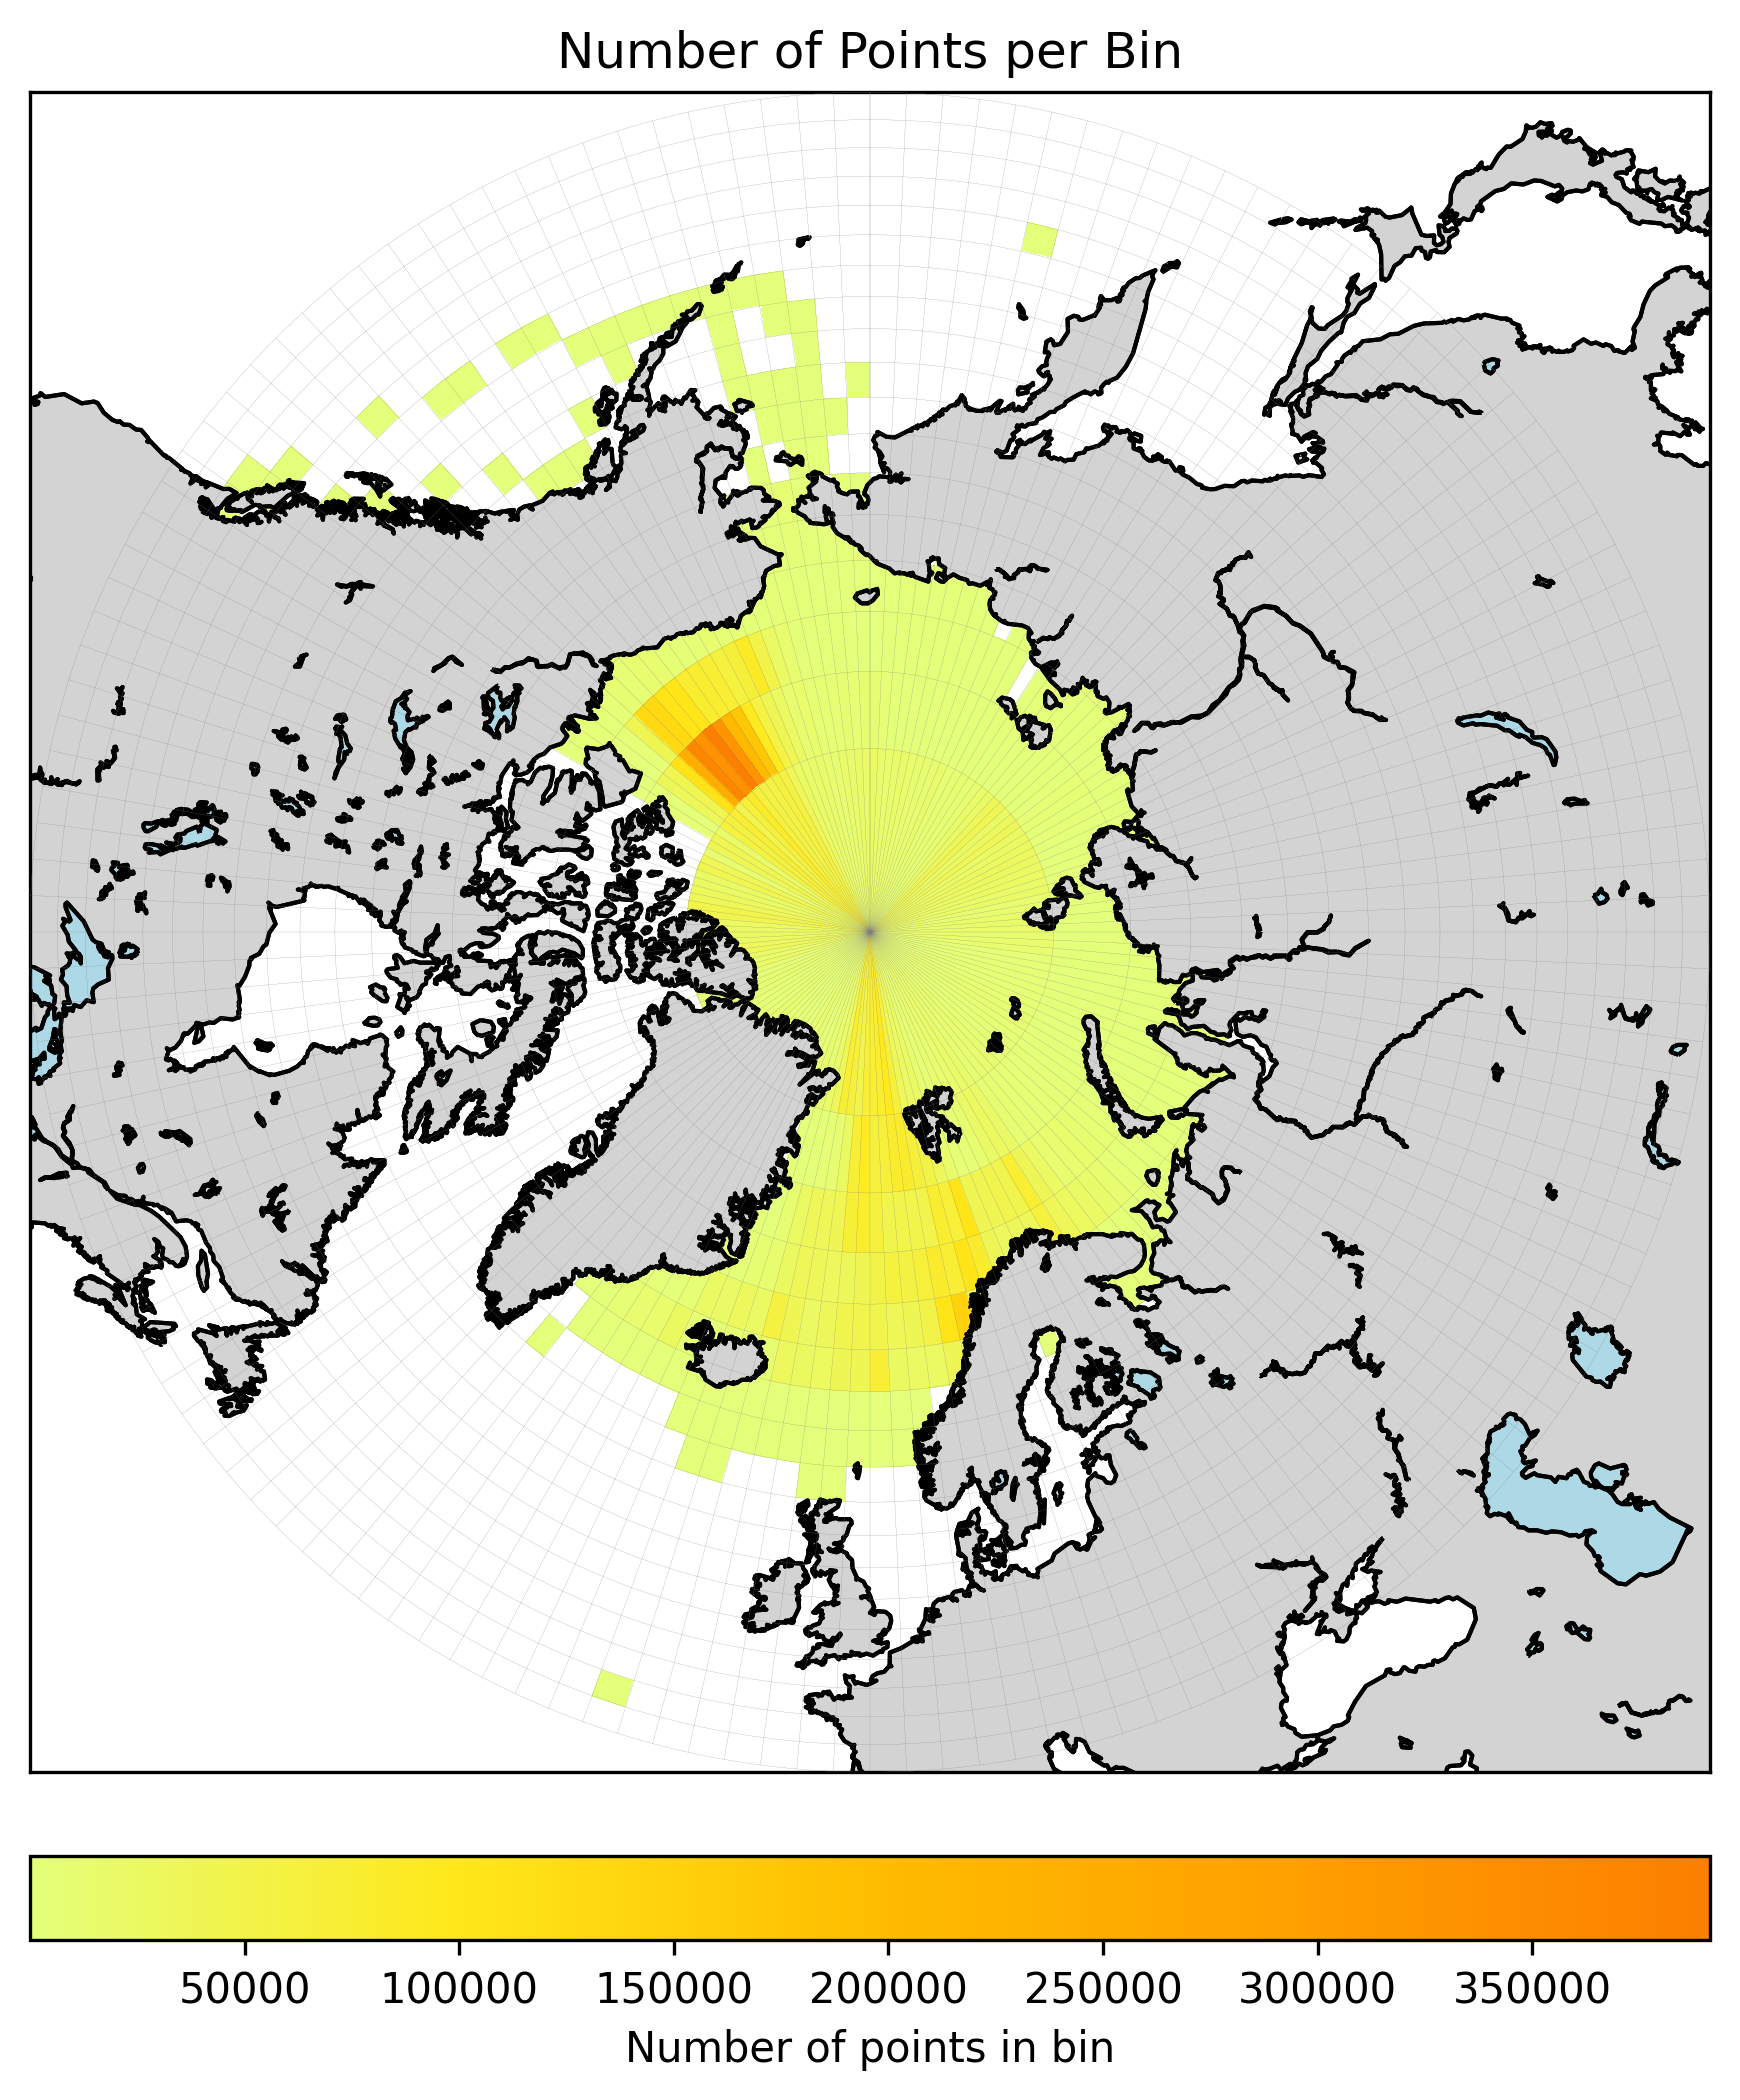

In [10]:
plot_heatmap_npts(df_ST, n_lon_bins=144, n_lat_bins=18)

# Method 2 - check if 1970s points change anything

In [ ]:
df_ST = df_ST[df_ST['year'] >= 1980]